In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [22]:
# Load the dataset
df = pd.read_csv("../data/raw/fake_job_postings.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [23]:
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [24]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 17880
Columns: 18


In [25]:
df.columns.tolist()

['job_id',
 'title',
 'location',
 'department',
 'salary_range',
 'company_profile',
 'description',
 'requirements',
 'benefits',
 'telecommuting',
 'has_company_logo',
 'has_questions',
 'employment_type',
 'required_experience',
 'required_education',
 'industry',
 'function',
 'fraudulent']

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   job_id               17880 non-null  int64
 1   title                17880 non-null  str  
 2   location             17534 non-null  str  
 3   department           6333 non-null   str  
 4   salary_range         2868 non-null   str  
 5   company_profile      14572 non-null  str  
 6   description          17879 non-null  str  
 7   requirements         15184 non-null  str  
 8   benefits             10668 non-null  str  
 9   telecommuting        17880 non-null  int64
 10  has_company_logo     17880 non-null  int64
 11  has_questions        17880 non-null  int64
 12  employment_type      14409 non-null  str  
 13  required_experience  10830 non-null  str  
 14  required_education   9775 non-null   str  
 15  industry             12977 non-null  str  
 16  function             11425 non-nu

In [27]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

salary_range           15012
department             11547
required_education      8105
benefits                7212
required_experience     7050
function                6455
industry                4903
employment_type         3471
company_profile         3308
requirements            2696
location                 346
description                1
dtype: int64

In [28]:
df["fraudulent"].value_counts()

fraudulent
0    17014
1      866
Name: count, dtype: int64

In [29]:
(df["fraudulent"].value_counts(normalize=True) * 100).round(2)

fraudulent
0    95.16
1     4.84
Name: proportion, dtype: float64

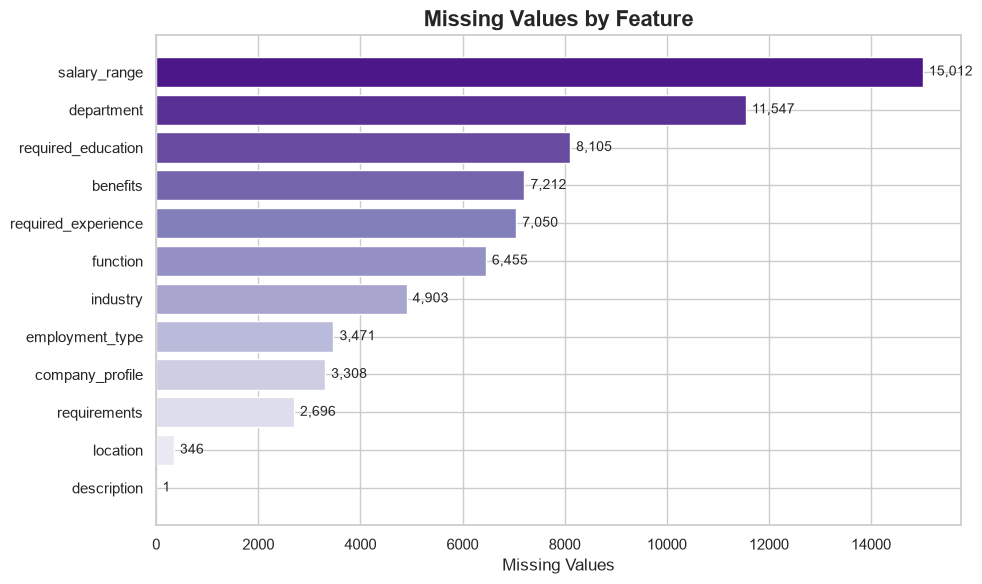

In [30]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values()

labels = missing.index.tolist()
values = missing.to_numpy(dtype=int)

plt.figure(figsize=(10, 6))

colors = sns.color_palette("Purples", len(values))

bars = plt.barh(
    labels,
    values,
    color=colors
)

for bar in bars:
    plt.text(
        float(bar.get_width()) + 120,
        float(bar.get_y()) + float(bar.get_height()) / 2,
        f"{int(bar.get_width()):,}",
        va="center",
        fontsize=10
    )

plt.title(
    "Missing Values by Feature",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Missing Values")

plt.tight_layout()

plt.savefig("../results/figures/missing_values.png", dpi=300)

plt.show()

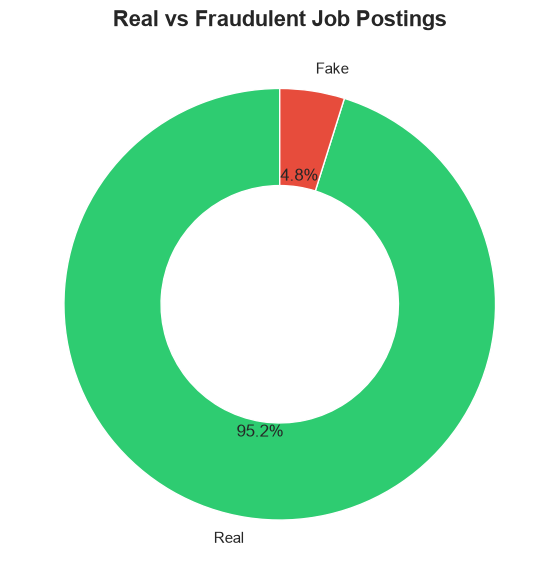

In [31]:
counts = df["fraudulent"].value_counts()

colors = ["#2ECC71", "#E74C3C"]

plt.figure(figsize=(6,6))

plt.pie(
    counts,
    labels=["Real","Fake"],
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.45, edgecolor="white")
)

plt.title("Real vs Fraudulent Job Postings",
          fontsize=16,
          weight="bold")

plt.tight_layout()

plt.savefig("../results/figures/fraud_donut.png", dpi=300)

plt.show()

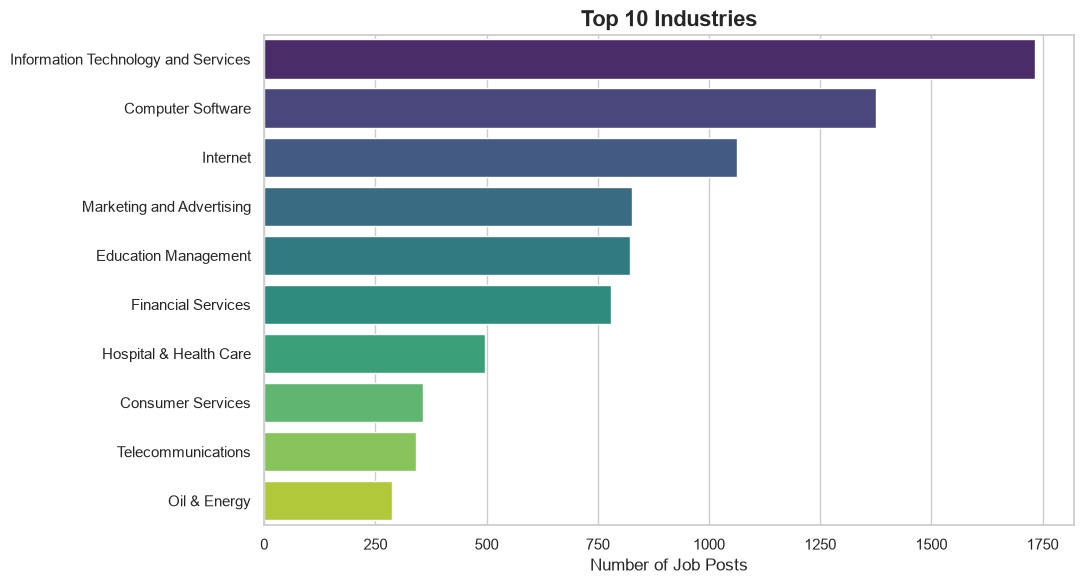

In [32]:
industry = df["industry"].value_counts().head(10)

plt.figure(figsize=(11,6))

sns.barplot(
    x=industry.values,
    y=industry.index,
    hue=industry.index,
    palette="viridis",
    legend=False
)

plt.title("Top 10 Industries",
          fontsize=16,
          weight="bold")

plt.xlabel("Number of Job Posts")

plt.ylabel("")

plt.tight_layout()

plt.savefig("../results/figures/top_industries.png", dpi=300)

plt.show()

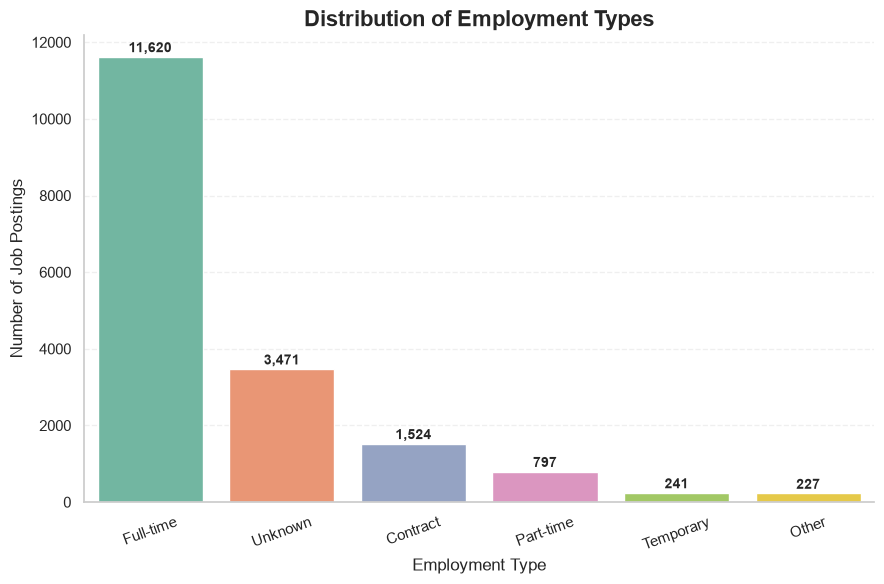

In [33]:
employment = (
    df["employment_type"]
    .fillna("Unknown")
    .value_counts()
)

plt.figure(figsize=(9,6))

colors = sns.color_palette("Set2", len(employment))

ax = sns.barplot(
    x=employment.index,
    y=employment.values,
    hue=employment.index,
    palette=colors,
    legend=False
)

plt.title(
    "Distribution of Employment Types",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Employment Type", fontsize=12)
plt.ylabel("Number of Job Postings", fontsize=12)

plt.xticks(rotation=20)

# Add value labels on top of bars
for i, value in enumerate(employment.values):
    ax.text(
        i,
        value + 120,
        f"{value:,}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.grid(axis="y", linestyle="--", alpha=0.3)

sns.despine()

plt.tight_layout()

plt.savefig(
    "../results/figures/employment_type_bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

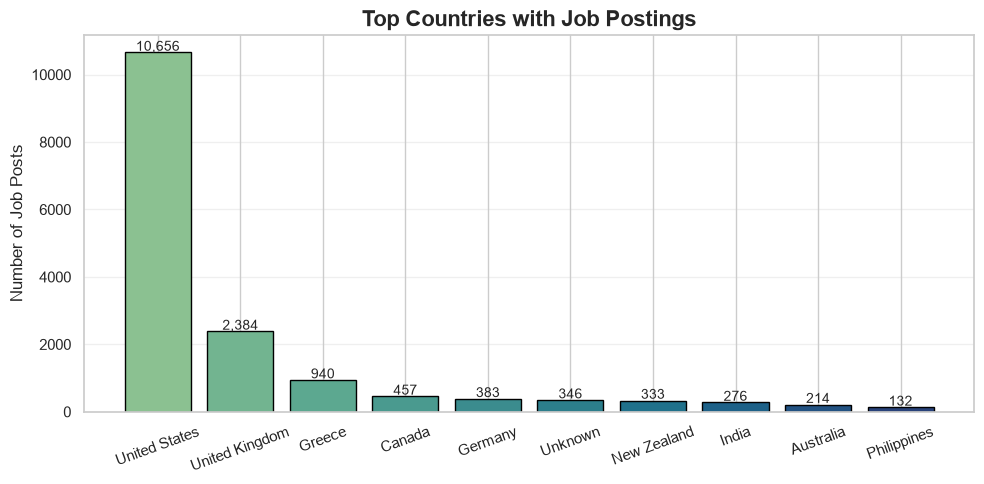

In [34]:
country = (
    df["location"]
      .fillna("Unknown")
      .str.split(",")
      .str[0]
)

country = country.replace({
    "US":"United States",
    "GB":"United Kingdom",
    "DE":"Germany",
    "AU":"Australia",
    "CA":"Canada",
    "GR":"Greece",
    "NZ":"New Zealand",
    "IN":"India",
    "PH":"Philippines"
})

top = country.value_counts().head(10)

plt.figure(figsize=(10,5))

colors = sns.color_palette("crest", len(top))

bars = plt.bar(
    top.index.tolist(),
    top.to_numpy(dtype=int),
    color=colors,
    edgecolor="black"
)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+50,
        f"{int(bar.get_height()):,}",
        ha="center",
        fontsize=10
    )

plt.xticks(rotation=20)

plt.ylabel("Number of Job Posts")

plt.title(
    "Top Countries with Job Postings",
    fontsize=16,
    weight="bold"
)

plt.grid(axis="y",alpha=.3)

plt.tight_layout()

plt.savefig("../results/figures/top_countries.png",dpi=300)

plt.show()

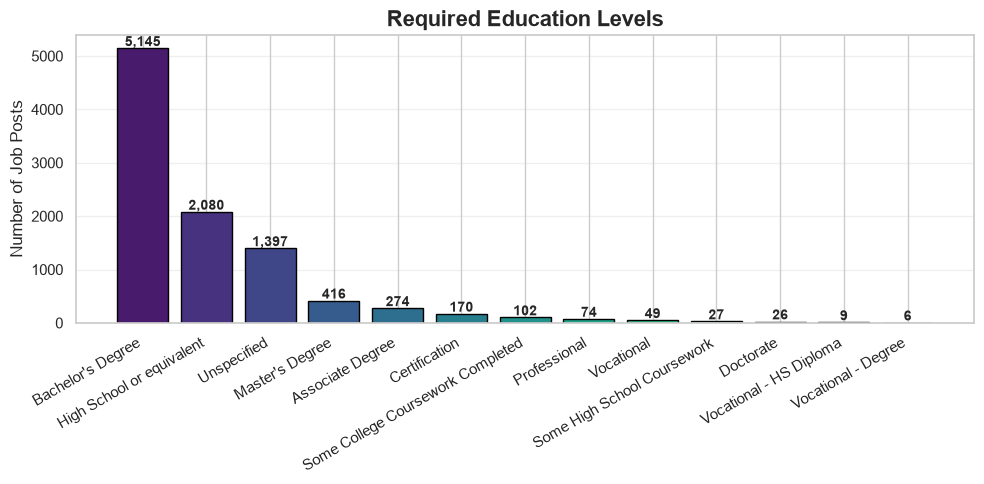

In [35]:
education = (
    df["required_education"]
    .fillna("Unknown")
    .value_counts()
)

education = education.drop("Unknown")

plt.figure(figsize=(10,5))

colors = sns.color_palette("viridis", len(education))

bars = plt.bar(
    education.index.tolist(),
    education.to_numpy(dtype=int),
    color=colors,
    edgecolor="black"
)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+40,
        f"{int(bar.get_height()):,}",
        ha="center",
        fontsize=10,
        weight="bold"
    )

plt.xticks(rotation=30, ha="right")
plt.ylabel("Number of Job Posts")
plt.title("Required Education Levels", fontsize=16, weight="bold")

plt.grid(axis="y", alpha=.3)

plt.tight_layout()

plt.savefig("../results/figures/required_education.png", dpi=300)

plt.show()

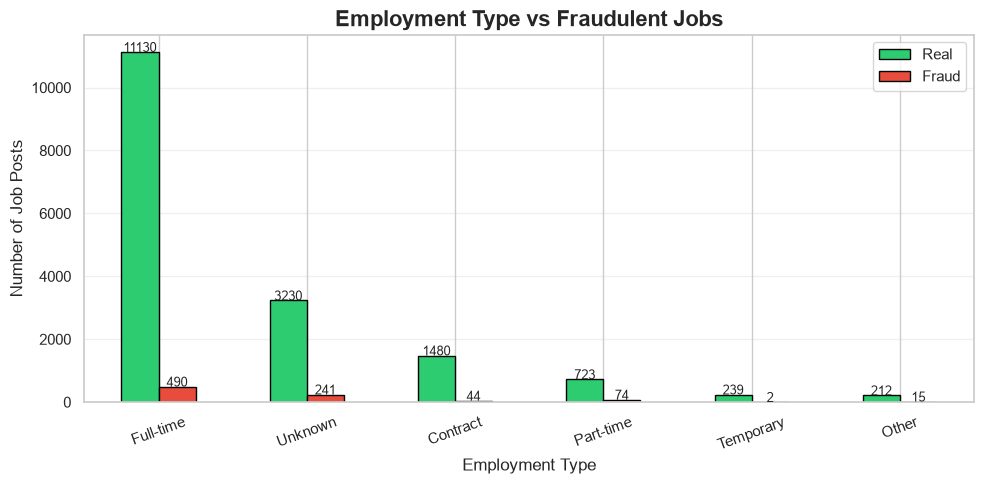

In [36]:
employment = pd.crosstab(
    df["employment_type"].fillna("Unknown"),
    df["fraudulent"]
)

employment.columns = ["Real", "Fraud"]

employment = employment.sort_values(
    by="Real",
    ascending=False
)

ax = employment.plot(
    kind="bar",
    figsize=(10, 5),
    color=["#2ecc71", "#e74c3c"],
    edgecolor="black"
)

for bars in ax.containers:
    for bar in bars:
        ax.text(
            float(bar.get_x()) + float(bar.get_width()) / 2,
            float(bar.get_height()) + 2,
            f"{int(bar.get_height())}",
            ha="center",
            fontsize=9
        )

plt.title(
    "Employment Type vs Fraudulent Jobs",
    fontsize=16,
    weight="bold"
)

plt.ylabel("Number of Job Posts")

plt.xlabel("Employment Type")

plt.xticks(rotation=20)

plt.grid(axis="y", alpha=.3)

plt.tight_layout()

plt.savefig("../results/figures/employment_vs_fraud.png", dpi=300)

plt.show()

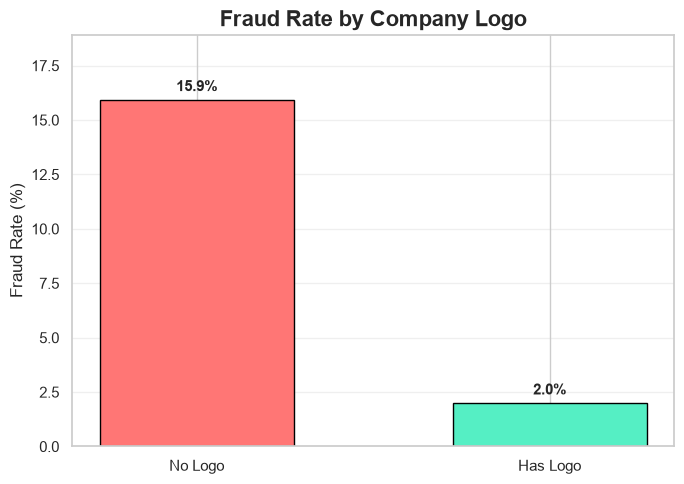

In [37]:
logo = (
    df.groupby("has_company_logo")["fraudulent"]
      .mean()
      .mul(100)
)

logo.index = ["No Logo", "Has Logo"]

plt.figure(figsize=(7,5))

colors = ["#ff7675", "#55efc4"]

bars = plt.bar(
    logo.index,
    logo.to_numpy(dtype=float),
    color=colors,
    edgecolor="black",
    width=.55
)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.4,
        f"{bar.get_height():.1f}%",
        ha="center",
        fontsize=11,
        weight="bold"
    )

plt.ylabel("Fraud Rate (%)")

plt.title(
    "Fraud Rate by Company Logo",
    fontsize=16,
    weight="bold"
)

plt.ylim(0,max(logo.values)+3)

plt.grid(axis="y",alpha=.3)

plt.tight_layout()

plt.savefig("../results/figures/logo_fraud_rate.png",dpi=300)

plt.show()

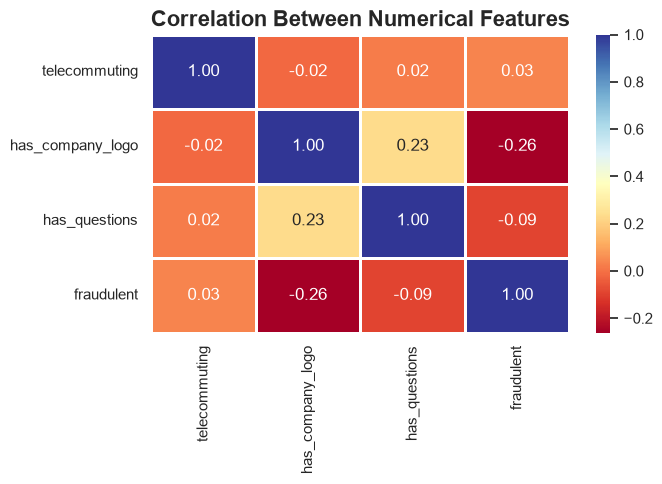

In [38]:
numeric = [
    "telecommuting",
    "has_company_logo",
    "has_questions",
    "fraudulent"
]

plt.figure(figsize=(7,5))

sns.heatmap(
    df[numeric].corr(),
    annot=True,
    cmap="RdYlBu",
    linewidths=1,
    fmt=".2f"
)

plt.title("Correlation Between Numerical Features", fontsize=16, fontweight="bold")

plt.tight_layout()

plt.savefig("../results/figures/correlation_heatmap.png", dpi=300)

plt.show()

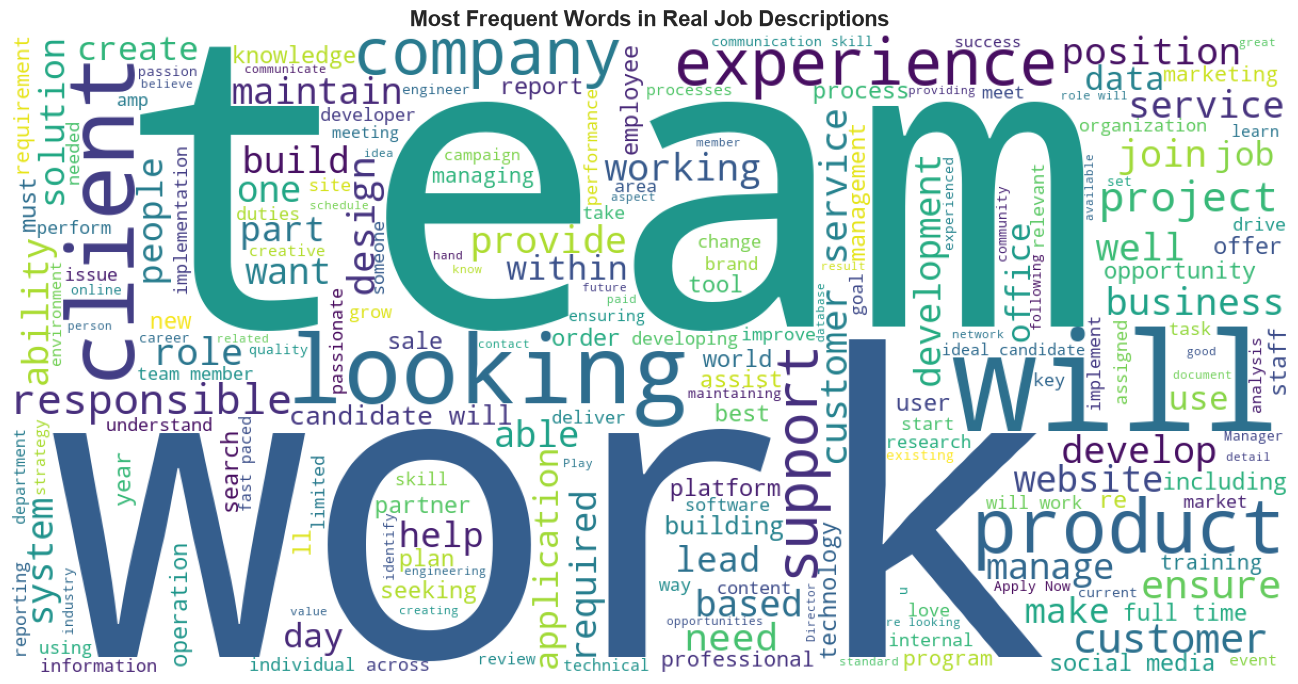

In [39]:
from wordcloud import WordCloud

real_text = " ".join(
    df[df["fraudulent"] == 0]["description"].fillna("")
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="viridis",
    max_words=200
).generate(real_text)

plt.figure(figsize=(14,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Most Frequent Words in Real Job Descriptions",
          fontsize=16,
          fontweight="bold")

plt.tight_layout()

plt.savefig("../results/figures/real_wordcloud.png", dpi=300)

plt.show()

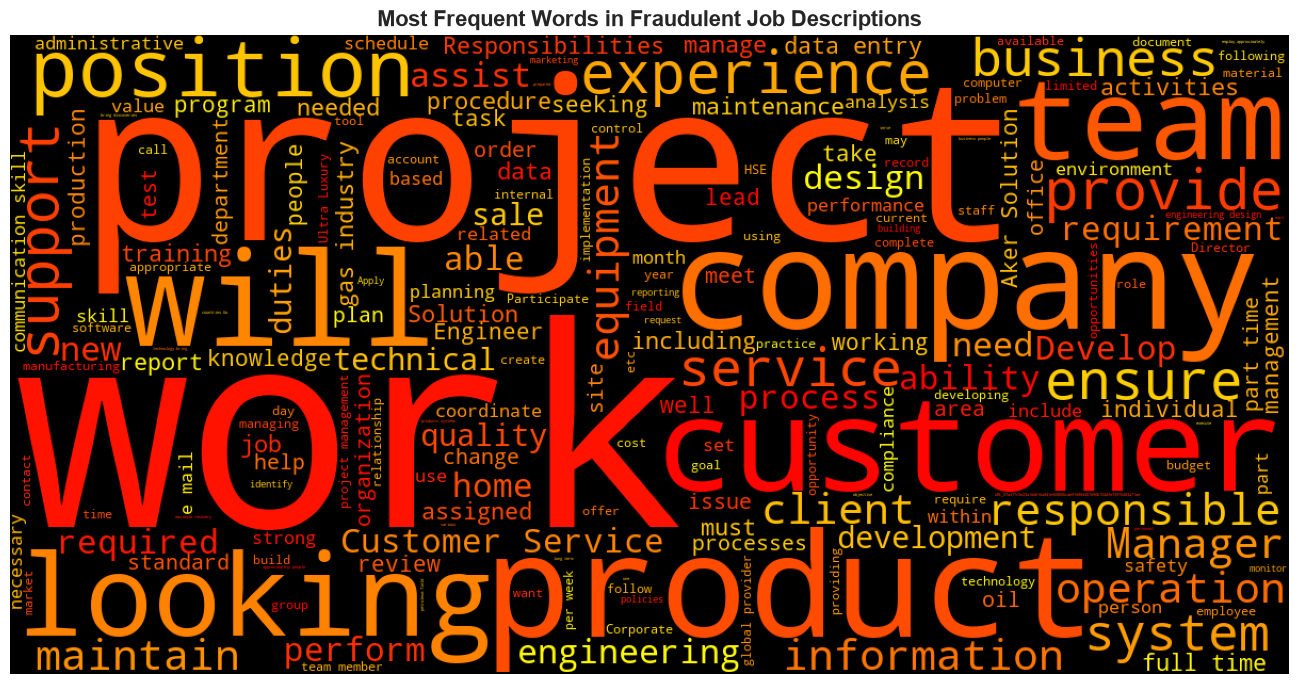

In [40]:
fraud_text = " ".join(
    df[df["fraudulent"] == 1]["description"].fillna("")
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="black",
    colormap="autumn",
    max_words=200
).generate(fraud_text)

plt.figure(figsize=(14,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Most Frequent Words in Fraudulent Job Descriptions",
          fontsize=16,
          fontweight="bold")

plt.tight_layout()

plt.savefig("../results/figures/fraud_wordcloud.png", dpi=300)

plt.show()